In [21]:
# Import modules
import rdkit
from IPython.display import SVG
from notebook_utils import draw_molecule
from rdkit.Chem import Draw

# Print versions
print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.1


In [22]:
# Load SMILES
smiles = "c1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C"
molecule_name = "Imatinib"
mol = rdkit.Chem.MolFromSmiles(smiles)

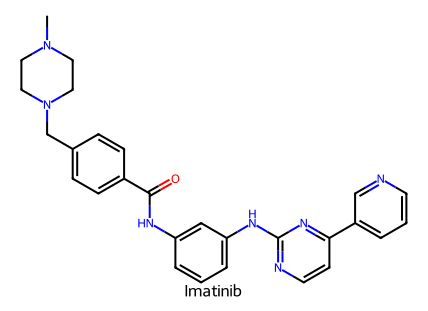

In [23]:
# Compute 2D coordinates
rdkit.Chem.rdDepictor.Compute2DCoords(mol)
rdkit.Chem.rdDepictor.StraightenDepiction(mol)

# Create drawer with specified dimensions
d2d = Draw.MolDraw2DSVG(-1, -1)

# Set up atom highlighting
highlight_atoms = None
highlight_atom_color = (0.9, 0.9, 0.0)
highlight_atom_map = {}
if highlight_atoms is not None:
    if isinstance(highlight_atom_color, tuple):
        highlight_atom_map = dict.fromkeys(highlight_atoms, highlight_atom_color)
    elif isinstance(highlight_atom_color, list):
        highlight_atom_map = dict(zip(highlight_atoms, highlight_atom_color, strict=True))
    else:
        raise ValueError(
            "highlight_atoms must be None or List[int] and highlight_atom_color must"
            + "be Tuple[float, float, float] or List[Tuple[float, float, float]]"
        )

# Set up bond highlighting
highlight_bonds = None
highlight_bond_color = (1, 0.5, 0.5)
highlight_bond_map = {}
if highlight_bonds is not None:
    if isinstance(highlight_bond_color, tuple):
        highlight_bond_map = dict.fromkeys(highlight_bonds, highlight_bond_color)
    elif isinstance(highlight_bond_color, list):
        highlight_bond_map = dict(zip(highlight_bonds, highlight_bond_color, strict=True))
    else:
        raise ValueError(
            "highlight_bonds must be None or List[int] and highlight_bond_color must"
            + "be Tuple[float, float, float] or List[Tuple[float, float, float]]"
        )

# Draw the molecule
d2d.DrawMolecule(
    mol,
    legend=molecule_name,
    highlightAtoms=highlight_atoms,
    highlightAtomColors=highlight_atom_map,
    highlightBonds=highlight_bonds,
    highlightBondColors=highlight_bond_map,
)

d2d.FinishDrawing()
img = d2d.GetDrawingText()
SVG(img)

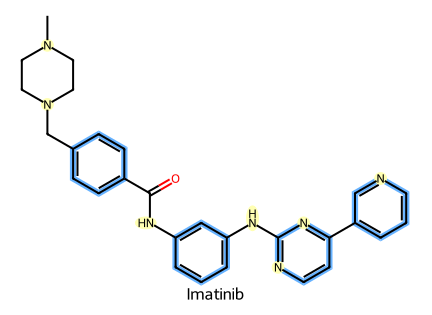

In [24]:
# Find all aromatic bonds in the molecule
aromatic_bonds = [bond.GetIdx() for bond in mol.GetBonds() if bond.GetIsAromatic()]

# Find all nitrogen atoms in the molecule
element_number = 7
nitrogen_atoms = [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetAtomicNum() == element_number]

img = draw_molecule(
    mol,
    legend=molecule_name,
    highlight_atoms=nitrogen_atoms,
    highlight_bonds=aromatic_bonds,
)
SVG(img)

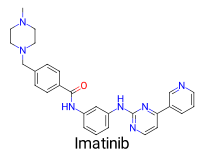

In [25]:
# Create drawer with specified dimensions
d2d = Draw.MolDraw2DSVG(-1, -1)

# Set ACS1996 Style
draw_options = d2d.drawOptions()
Draw.SetACS1996Mode(draw_options, Draw.MeanBondLength(mol))
draw_options.useDefaultAtomPalette()

# Draw the molecule
d2d.DrawMolecule(
    mol,
    legend=molecule_name,
)

d2d.FinishDrawing()
img = d2d.GetDrawingText()
SVG(img)

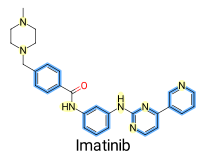

In [26]:
# ACS1996 Style Function
img = draw_molecule(
    mol,
    legend=molecule_name,
    highlight_atoms=nitrogen_atoms,
    highlight_bonds=aromatic_bonds,
    acs_style=True,
)
SVG(img)